Iniciando simulación del SOA...
Simulando propagación en SOA...
BER = 6.105e-05 | Offset Óptimo: 16
Generando gráficas ANTES de la BiLSTM...


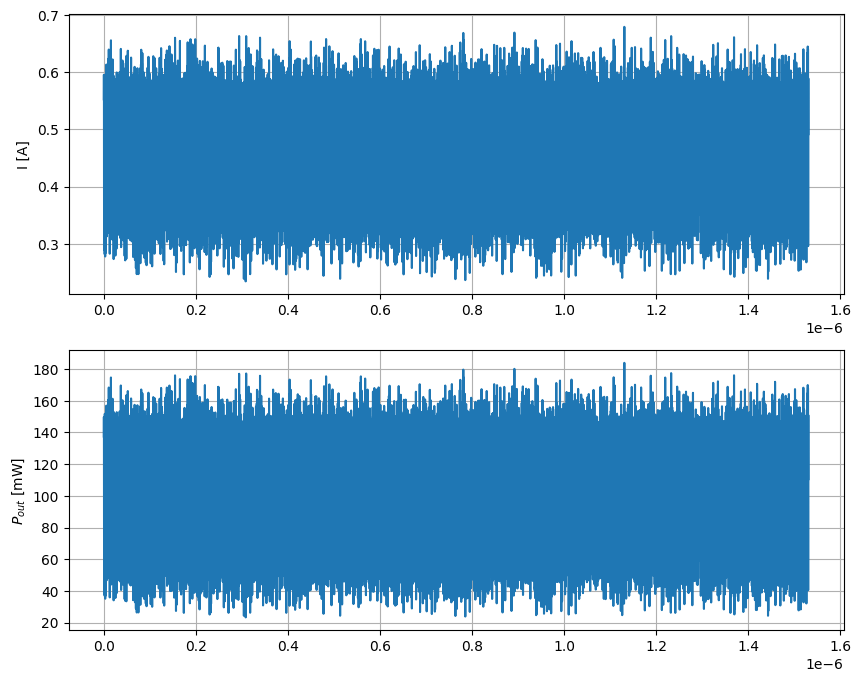

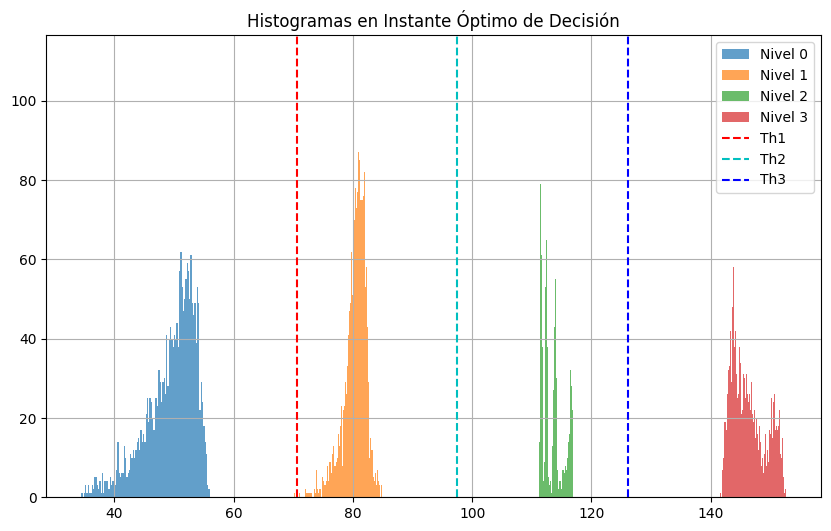

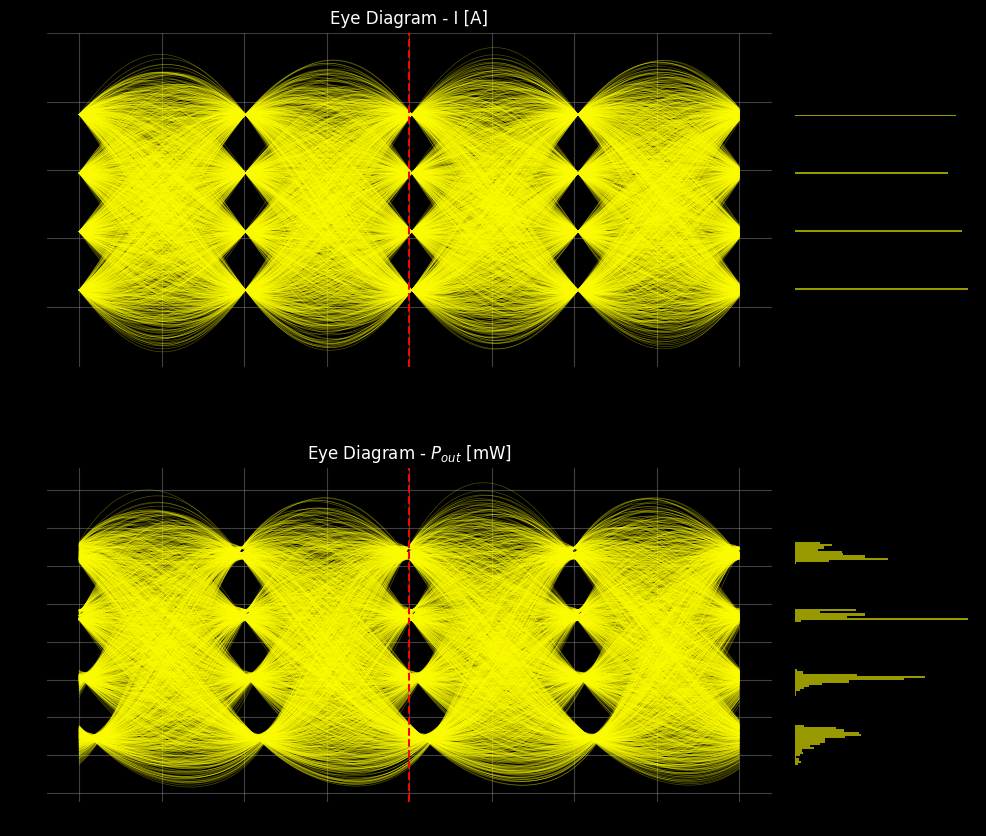

In [1]:
# Importaciones estándar y de ML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time

# Importaciones de tus códigos locales
from params import SOAparams
from soa_main import run_simulation, plot_results, plot_eye_diagrams, plot_single_eye_with_hist

# Instanciar parámetros globales
p = SOAparams()
WINDOW_SIZE = 32

print("Iniciando simulación del SOA...")
# Llamamos a la función de soa_main.py
# I_trim es la corriente ideal (PAM-4)
# P_out_trim es la potencia óptica distorsionada
I_trim, P_out_trim, P_levels, thresholds, off_best = run_simulation()

print("Generando gráficas ANTES de la BiLSTM...")

# 1. Gráficas de resultados y los histogramas generados aparte
plot_results(I_trim, P_out_trim, P_levels, thresholds, p.sample_period)

# 2. Los ojos originales y sus histogramas laterales
plot_eye_diagrams(I_trim, P_out_trim, p.samples_per_bit, off_best)

plt.show()

In [2]:
# Creamos el DataFrame mapeando las variables de la simulación a tu código
df = pd.DataFrame({
    'Time_s': np.arange(len(I_trim)) * p.sample_period,
    'Current_Input_A': I_trim,          # Señal Ideal a predecir (y)
    'Power_Output_mW': P_out_trim * 1e3 # Señal Distorsionada de entrada (X)
})

def load_and_prep_data(df, window_size):
    X_raw = df['Power_Output_mW'].values.reshape(-1, 1)
    y_raw = df['Current_Input_A'].values.reshape(-1, 1)
    
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    X_scaled = scaler_X.fit_transform(X_raw)
    y_scaled = scaler_y.fit_transform(y_raw)
    
    X_seq, y_seq = [], []
    offset = window_size // 2 
    for i in range(len(X_scaled) - window_size):
        X_seq.append(X_scaled[i : i + window_size])
        y_seq.append(y_scaled[i + offset])
        
    return np.array(X_seq), np.array(y_seq), scaler_X, scaler_y

X, y, scaler_X, scaler_y = load_and_prep_data(df, WINDOW_SIZE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [3]:
model = Sequential([
    Input(shape=(WINDOW_SIZE, 1)), 
    Bidirectional(LSTM(units=50, return_sequences=False)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear') 
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("Entrenando BiLSTM...")
t_train = time.time()
history = model.fit(
    X_train, y_train,
    epochs=15, 
    batch_size=256, 
    validation_split=0.1,
    verbose=1
)
print(f"Tiempo de entrenamiento: {(time.time() - t_train):.2f} s")

print("Realizando inferencia con los datos de prueba...")
y_pred_scaled = model.predict(X_test)

# Desescalar
y_pred_unaligned = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_true_unaligned = scaler_y.inverse_transform(y_test).flatten()

# Corrección de desfase para mantener sincronía con el centro del ojo (samples_per_bit)
test_start_index = len(X_train) + (WINDOW_SIZE // 2)
shift = (p.samples_per_bit - (test_start_index % p.samples_per_bit)) % p.samples_per_bit

y_pred = y_pred_unaligned[shift:]
y_true = y_true_unaligned[shift:]

Entrenando BiLSTM...
Epoch 1/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - loss: 0.0027 - val_loss: 4.5733e-05
Epoch 2/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - loss: 4.1286e-05 - val_loss: 3.2044e-05
Epoch 3/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - loss: 3.2637e-05 - val_loss: 2.1310e-05
Epoch 4/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - loss: 2.6615e-05 - val_loss: 3.9731e-05
Epoch 5/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - loss: 2.3683e-05 - val_loss: 2.5714e-05
Epoch 6/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - loss: 1.9132e-05 - val_loss: 2.0108e-05
Epoch 7/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - loss: 1.6345e-05 - val_loss: 3.2871e-05
Epoch 8/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - loss: 1.5199e-05 - val_loss: 2.9605e-05
Epoch 9/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 1.2978e-05 - val_loss: 8.0873e-06
Epoch 10/15
737/737 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 1.1143e-05 - val_loss: 7.0201e-06
Epoch 11/15
737/737 ━━

In [4]:
from sklearn.cluster import KMeans

# Extraemos muestras en el centro del ojo para y_pred y y_true
UI = p.samples_per_bit
offset = UI // 2
centers = np.arange(offset, len(y_pred), UI)

P_samp_true = y_true[centers]
P_samp_pred = y_pred[centers]

# Usamos KMeans para agrupar en EXACTAMENTE 4 niveles (PAM-4) 
# y evitar variaciones causadas por el filtro gaussiano
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(P_samp_true.reshape(-1, 1))
labels = kmeans.labels_

# Ordenamos los clusters del nivel de corriente más bajo al más alto
cluster_means = [np.mean(P_samp_true[labels == i]) for i in range(4)]
sorted_clusters = np.argsort(cluster_means)

# Guardamos los niveles predichos respetando el orden (del nivel 0 al 3)
P_levels_pred = [P_samp_pred[labels == i] for i in sorted_clusters]

mu = np.array([np.mean(lvl) for lvl in P_levels_pred])
sg = np.array([np.std(lvl) for lvl in P_levels_pred])

# Umbrales dinámicos basados en la predicción de la red
Th1_nn = (sg[0]*mu[1] + sg[1]*mu[0]) / (sg[0] + sg[1])
Th2_nn = (sg[1]*mu[2] + sg[2]*mu[1]) / (sg[1] + sg[2])
Th3_nn = (sg[2]*mu[3] + sg[3]*mu[2]) / (sg[2] + sg[3])

# Clasificar símbolos predichos (valores 1, 2, 3, 4)
sym_hat = np.zeros_like(P_samp_pred)
sym_hat[P_samp_pred < Th1_nn] = 1
sym_hat[(P_samp_pred >= Th1_nn) & (P_samp_pred < Th2_nn)] = 2
sym_hat[(P_samp_pred >= Th2_nn) & (P_samp_pred < Th3_nn)] = 3
sym_hat[P_samp_pred >= Th3_nn] = 4

# Generar los símbolos reales (tx) a partir de los clusters ordenados ideales
sym_tx = np.zeros_like(labels)
for new_idx, original_cluster in enumerate(sorted_clusters):
    sym_tx[labels == original_cluster] = new_idx + 1

SER_nn = np.mean(sym_hat != sym_tx)

# Mapeo Gray inverso para BER
def sym2bits(s_arr):
    b2 = (s_arr == 2) | (s_arr == 3)
    b1 = (s_arr == 1) | (s_arr == 2)
    return np.column_stack((b2, b1)).ravel()

bits_tx = sym2bits(sym_tx)
bits_hat = sym2bits(sym_hat)
BER_nn = np.mean(bits_tx != bits_hat)

print("--- RESULTADOS DESPUÉS DE LA BiLSTM ---")
# print(f"SER = {SER_nn:.3e} (errores={np.sum(sym_hat != sym_tx)} de {len(sym_tx)})")
print(f"BER = {BER_nn:.3e} (errores={np.sum(bits_tx != bits_hat)} de {len(bits_tx)})")

--- RESULTADOS DESPUÉS DE LA BiLSTM ---
BER = 0.000e+00 (errores=0 de 3274)


c:\Users\natan\anaconda3\envs\env1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


Generando gráficas DESPUÉS de la BiLSTM...


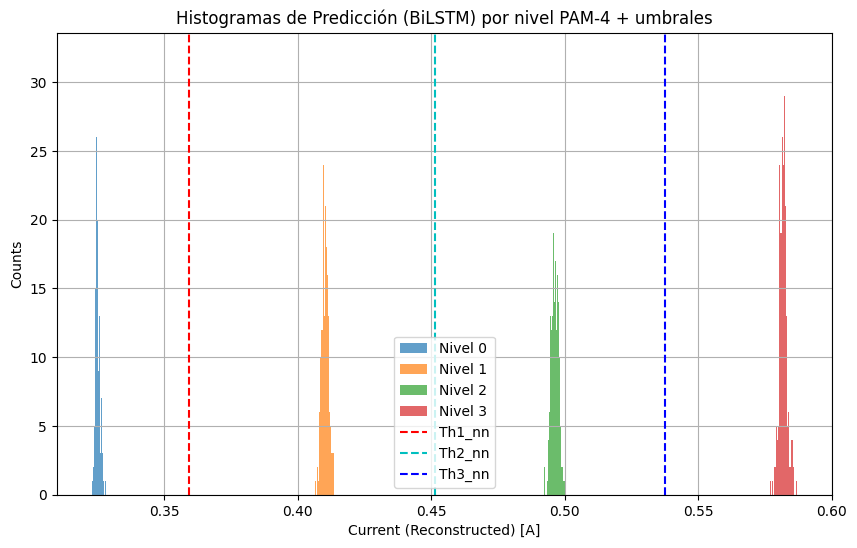

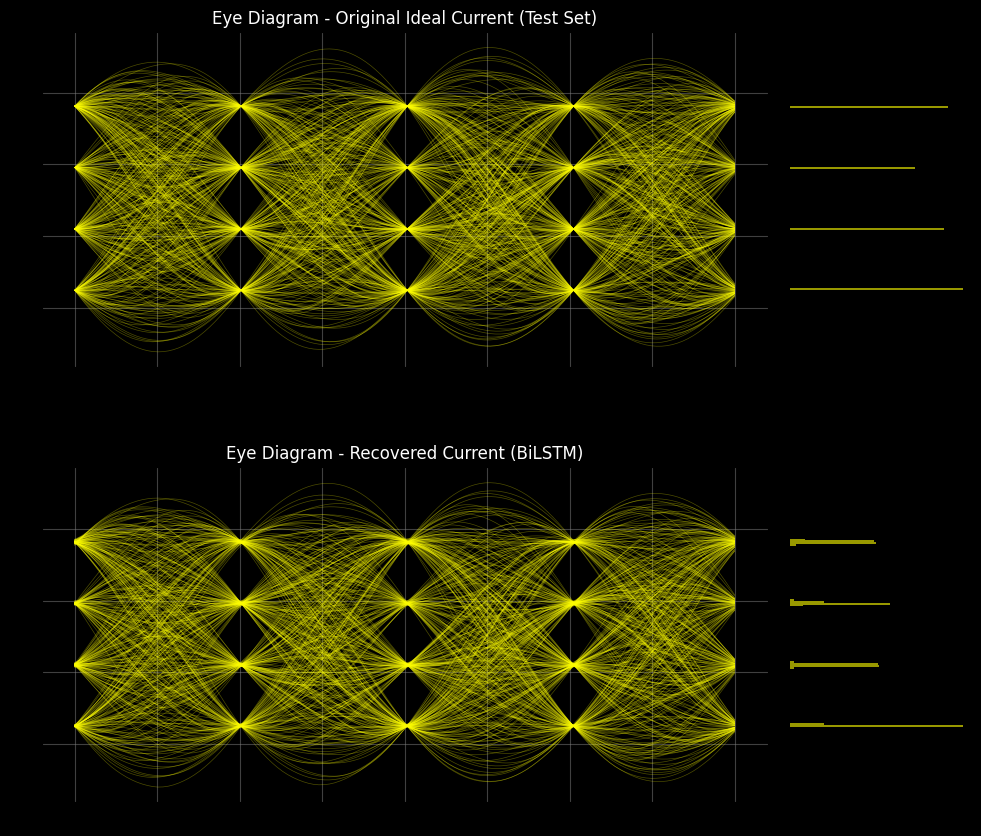

In [7]:
print("Generando gráficas DESPUÉS de la BiLSTM...")

# 1. Histogramas que se generan aparte (Comparación de umbrales)
plt.figure(figsize=(10, 6))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, P_vals in enumerate(P_levels_pred):
    plt.hist(P_vals, bins=50, alpha=0.7, color=colors[i], label=f'Nivel {i}')

plt.axvline(Th1_nn, color='r', linestyle='--', linewidth=1.5, label='Th1_nn')
plt.axvline(Th2_nn, color='c', linestyle='--', linewidth=1.5, label='Th2_nn')
plt.axvline(Th3_nn, color='b', linestyle='--', linewidth=1.5, label='Th3_nn')

plt.xlabel('Current (Reconstructed) [A]')
plt.ylabel('Counts')
plt.title('Histogramas de Predicción (BiLSTM) por nivel PAM-4 + umbrales')
plt.legend()
plt.grid(True)
plt.show()

# 2. Ojos comparativos: Original Ideal vs Reconstruido por la RNN
# Aprovechamos la función plot_eye_diagrams que ya tenías
# Nota: La gráfica dirá "I" arriba y "P_out" abajo por defecto en tu función original, 
# pero aquí representan la Corriente Ideal vs Corriente Reconstruida.
fig = plt.figure(figsize=(12, 10), facecolor='black')
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], wspace=0.05, hspace=0.3)

# Ojo Original Ideal (Test Set)
ax_eye_1 = plt.subplot(gs[0, 0])
ax_hist_1 = plt.subplot(gs[0, 1], sharey=ax_eye_1)

# Se agrega el argumento 1.0 para unit_scale
plot_single_eye_with_hist(ax_eye_1, ax_hist_1, y_true.flatten(), p.samples_per_bit, 
                          'Eye Diagram - Original Ideal Current (Test Set)', 
                          'I [A]', 1.0, offset_samples=offset)

# Ojo Reconstruido (BiLSTM)
ax_eye_2 = plt.subplot(gs[1, 0])
ax_hist_2 = plt.subplot(gs[1, 1], sharey=ax_eye_2)

# Se agrega el argumento 1.0 para unit_scale
plot_single_eye_with_hist(ax_eye_2, ax_hist_2, y_pred.flatten(), p.samples_per_bit, 
                          'Eye Diagram - Recovered Current (BiLSTM)', 
                          'I [A]', 1.0, offset_samples=offset)

plt.show()

🧹 Preprocesando datos para el Teacher...
📊 Dataset listo: 209560 muestras de entrenamiento.

Construyendo el modelo Teacher...



Model: "Teacher_SOA_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 64)   │        384 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 64)   │     12,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 64, 64)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64, 128)   │     49,920 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_attention    │ (None, 64, 128)   │     16,641 │ bidirectional_1[… │
│ (SimpleAttention)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ simple_attention… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      4,160 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      4,160 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64)        │          0 │ dense_4[0][0],    │
│                     │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      2,080 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 98,242 (383.76 KB)

 Trainable params: 98,114 (383.26 KB)

 Non-trainable params: 128 (512.00 B)


Iniciando entrenamiento (de la mas alta calidad)...
Epoch 1/60
696/696 ━━━━━━━━━━━━━━━━━━━━ 88s 120ms/step - loss: 0.0263 - val_loss: 0.0110 - learning_rate: 0.0010
Epoch 2/60
696/696 ━━━━━━━━━━━━━━━━━━━━ 80s 115ms/step - loss: 0.0098 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 3/60
696/696 ━━━━━━━━━━━━━━━━━━━━ 81s 117ms/step - loss: 0.0078 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 4/60
696/696 ━━━━━━━━━━━━━━━━━━━━ 80s 115ms/step - loss: 0.0068 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 5/60
696/696 ━━━━━━━━━━━━━━━━━━━━ 81s 116ms/step - loss: 0.0063 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 6/60
696/696 ━━━━━━━━━━━━━━━━━━━━ 79s 114ms/step - loss: 0.0060 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 7/60
696/696 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0058
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
696/696 ━━━━━━━━━━━━━━━━━━━━ 83s 120ms/step - loss: 0.0057 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 8/60
696/696 ━━

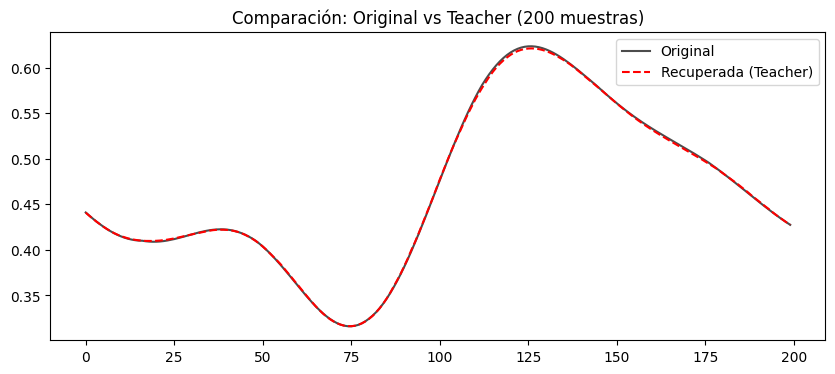

In [8]:
# ==========================================
# CELDA N: MODELO TEACHER (ATENCIÓN + RESIDUAL)
# ==========================================
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from params import SOAparams

# 1. COMPONENTES DEL TEACHER
# Pérdida combinada para forzar exactitud en los centros de los niveles
def combined_loss(y_true, y_pred):
    # Usamos las matemáticas directas del backend (K) a prueba de balas
    mse = K.mean(K.square(y_true - y_pred))
    mae = K.mean(K.abs(y_true - y_pred))
    return 0.7 * mse + 0.3 * mae

# Capa de Atención para identificar transiciones críticas del SOA
class SimpleAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W = layers.Dense(self.units, activation='tanh')
        self.V = layers.Dense(1)
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        score = self.V(self.W(inputs))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * inputs
        return context_vector

# 2. CONFIGURACIÓN Y DATOS
p = SOAparams()
WINDOW_SIZE = int(p.samples_per_bit * 4) # (4 bits)

# CORRECCIÓN: Usamos las variables I_trim y P_out_trim de tu simulador
df = pd.DataFrame({
    'Current_Input_A': I_trim,
    'Power_Output_mW': P_out_trim * 1e3 
})

def load_and_prep_data(df, window_size):
    X_raw = df['Power_Output_mW'].values.reshape(-1, 1)
    y_raw = df['Current_Input_A'].values.reshape(-1, 1)
    
    scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X_raw)
    y_scaled = scaler_y.fit_transform(y_raw)
    
    X_seq, y_seq = [], []
    offset = window_size // 2 
    for i in range(len(X_scaled) - window_size):
        X_seq.append(X_scaled[i : i + window_size])
        y_seq.append(y_scaled[i + offset])
        
    return np.array(X_seq), np.array(y_seq), scaler_X, scaler_y

print("🧹 Preprocesando datos para el Teacher...")
X, y, scaler_X, scaler_y = load_and_prep_data(df, WINDOW_SIZE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"📊 Dataset listo: {len(X_train)} muestras de entrenamiento.")

# 3. ARQUITECTURA DEL MODELO TEACHER
def build_teacher_model(window_size):
    inputs = layers.Input(shape=(window_size, 1))

    # Bloque 1: ADCNN (Extracción de Características con Dilatación)
    c = layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(inputs)
    c = layers.BatchNormalization()(c)
    c = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', dilation_rate=2)(c)
    c = layers.MaxPooling1D(pool_size=2)(c) 

    # Bloque 2: BiGRU con Atención
    r = layers.Bidirectional(layers.GRU(64, return_sequences=True))(c)
    a = SimpleAttention(128)(r)
    a = layers.GlobalAveragePooling1D()(a)

    # Bloque 3: Refinamiento Residual (Deep Refiner) 
    dense_base = layers.Dense(64, activation='relu')(a)
    
    res = layers.Dense(64, activation='relu')(dense_base)
    res = layers.Dense(64, activation='relu')(res)
    
    # Suma residual: Base + Refinamiento
    combined = layers.Add()([dense_base, res])

    # Salida: Soft-Decision Mapping
    x = layers.Dense(32, activation='relu')(combined)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Teacher_SOA_ResNet")
    model.compile(optimizer=Adam(learning_rate=0.001), loss=combined_loss)
    return model

print("\nConstruyendo el modelo Teacher...")
teacher = build_teacher_model(WINDOW_SIZE)
teacher.summary()

# 4. ENTRENAMIENTO DE ALTA PRECISIÓN
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-7, verbose=1)

print("\nIniciando entrenamiento (de la mas alta calidad)...")
history = teacher.fit(
    X_train, y_train,
    epochs=60, 
    batch_size=256, 
    validation_split=0.15,
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

# 5. INFERENCIA Y ALINEACIÓN DE FASE
print("\nHaciendo predicciones en el set de prueba...")
y_pred_scaled = teacher.predict(X_test)
y_pred_un = scaler_y.inverse_transform(y_pred_scaled)
y_true_un = scaler_y.inverse_transform(y_test)

# Sincronización de bits para poder graficar diagramas de ojo
test_start_index = len(X_train) + (WINDOW_SIZE // 2)
shift = (p.samples_per_bit - (test_start_index % p.samples_per_bit)) % p.samples_per_bit

y_pred = y_pred_un[shift:].flatten()
y_true = y_true_un[shift:].flatten()

print("✅ ¡Inferencia completada y alineada!")

# --- Opcional: Grafiquita rápida para ver si jaló ---
plt.figure(figsize=(10,4))
plt.plot(y_true[:200], 'k-', label='Original', alpha=0.7)
plt.plot(y_pred[:200], 'r--', label='Recuperada (Teacher)')
plt.title('Comparación: Original vs Teacher (200 muestras)')
plt.legend()
plt.show()

👁️ Generando Comparativa de Diagramas de Ojo e Histogramas...


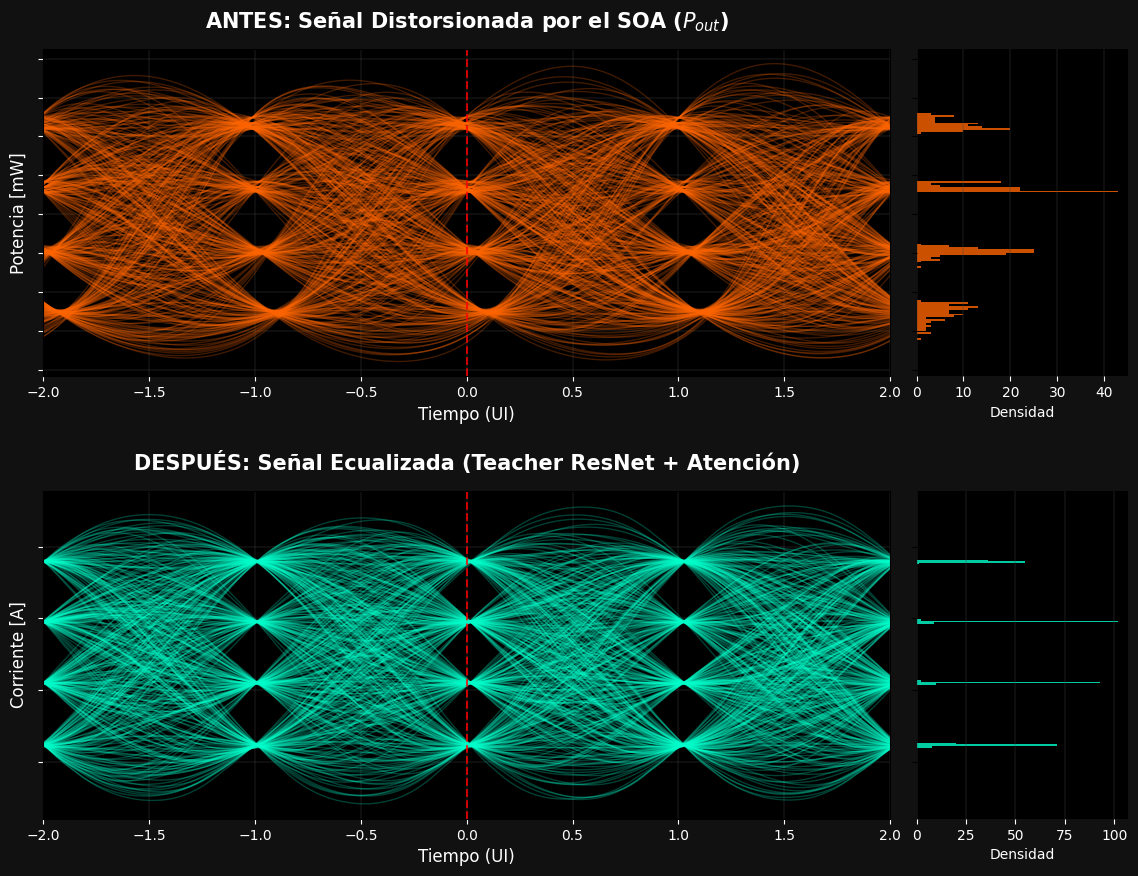

In [9]:
# ==========================================
# CELDA: DIAGRAMAS DE OJO ULTRA HD (ANTES VS DESPUÉS)
# ==========================================
import matplotlib.gridspec as gridspec

# 1. Extraemos la señal distorsionada alineada exactamente con nuestras predicciones
# test_start_index y shift ya fueron calculados en la celda anterior
P_out_test_aligned = df['Power_Output_mW'].values[test_start_index + shift : test_start_index + shift + len(y_pred)]

# 2. Función de graficado de alta calidad (Estilo Osciloscopio Profesional)
def plot_comparativa_ojos(distorsionada, recuperada, UI):
    offset = UI // 2
    
    # Fondo oscuro elegante para resaltar los colores neón
    fig = plt.figure(figsize=(14, 10), facecolor='#111111') 
    gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], wspace=0.05, hspace=0.35)
    
    def draw_eye_hist(ax_eye, ax_hist, signal, title, ylabel, color):
        span_ui = 4 
        samples_per_span = span_ui * UI
        signal_shifted = signal[offset:]
        n_traces = len(signal_shifted) // samples_per_span
        
        if n_traces == 0: return
            
        signal_cut = signal_shifted[:n_traces * samples_per_span]
        eye_matrix = signal_cut.reshape((n_traces, samples_per_span))
        t_span = np.linspace(-span_ui/2, span_ui/2, samples_per_span)
        
        # --- DIBUJAR OJO ---
        # alpha=0.25 para que se note la densidad (calor) donde pasan más trazas
        ax_eye.plot(t_span, eye_matrix.T, color=color, alpha=0.25, linewidth=1.0)
        ax_eye.set_facecolor('#000000')
        ax_eye.set_title(title, color='white', fontsize=15, fontweight='bold', pad=15)
        ax_eye.set_ylabel(ylabel, color='white', fontsize=12)
        ax_eye.set_xlabel('Tiempo (UI)', color='white', fontsize=12)
        ax_eye.tick_params(axis='x', colors='white')
        ax_eye.tick_params(axis='y', colors='white')
        ax_eye.set_xlim([-span_ui/2, span_ui/2])
        
        # Cuadrícula sutil
        ax_eye.grid(True, which='both', linestyle='-', linewidth=0.3, color='#444444')
        # Línea central ideal de muestreo
        ax_eye.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8) 

        # --- DIBUJAR HISTOGRAMA LATERAL ---
        center_idx = samples_per_span // 2
        samples_at_center = eye_matrix[:, center_idx]
        
        ax_hist.hist(samples_at_center, bins=120, color=color, alpha=0.8, orientation='horizontal')
        ax_hist.set_facecolor('#000000')
        ax_hist.tick_params(axis='x', colors='white')
        ax_hist.set_yticklabels([]) # Ocultar números del eje Y del histograma
        ax_hist.set_xlabel('Densidad', color='white', fontsize=10)
        ax_hist.grid(True, axis='x', linestyle='-', linewidth=0.3, color='#444444')
        ax_hist.set_ylim(ax_eye.get_ylim())
        
        # Limpiar bordes del histograma
        for spine in ax_hist.spines.values(): spine.set_visible(False)

    # Fila 1: EL DESASTRE (Señal Distorsionada) - Naranja Eléctrico
    ax_eye_1 = plt.subplot(gs[0, 0])
    ax_hist_1 = plt.subplot(gs[0, 1], sharey=ax_eye_1)
    draw_eye_hist(ax_eye_1, ax_hist_1, distorsionada, 
                  'ANTES: Señal Distorsionada por el SOA ($P_{out}$)', 'Potencia [mW]', '#FF6600')

    # Fila 2: LA MAGIA (Señal Recuperada por la IA) - Cian/Verde Neón
    ax_eye_2 = plt.subplot(gs[1, 0])
    ax_hist_2 = plt.subplot(gs[1, 1], sharey=ax_eye_2)
    draw_eye_hist(ax_eye_2, ax_hist_2, y_pred, 
                  'DESPUÉS: Señal Ecualizada (Teacher ResNet + Atención)', 'Corriente [A]', '#00FFCC')
    
    plt.show()

# 3. ¡Disparar la gráfica!
print("👁️ Generando Comparativa de Diagramas de Ojo e Histogramas...")
plot_comparativa_ojos(P_out_test_aligned, y_pred, p.samples_per_bit)

In [10]:

# ==========================================
# CÁLCULO DE BER DESPUÉS DEL TEACHER (IA)
# ==========================================
def calculate_ber_ia(y_pred_eval, y_true_eval, UI, off_best):
    # Aseguramos que las señales estén alineadas
    # y_pred_eval es la salida de la red (corriente recuperada)
    # y_true_eval es la corriente ideal
    
    # 1. Muestreo en el instante óptimo
    # Como y_pred_eval es una sección de la señal completa, 
    # necesitamos ajustar el offset si es necesario, 
    # pero aquí asumimos que y_pred_eval empieza en un punto conocido.
    
    # Encontramos los símbolos reales a partir de y_true_eval (Ground Truth)
    # Para PAM-4, podemos usar los umbrales ideales o cuantizar
    def get_symbols(sig, ui, off):
        samples = sig[off::ui]
        # Usamos KMeans o simplemente cuantización para obtener los símbolos de referencia
        from sklearn.cluster import KMeans
        kmeans = KMeans(n_clusters=4, n_init=10).fit(samples.reshape(-1, 1))
        # Ordenar centros para mapear a 0,1,2,3
        centers = np.sort(kmeans.cluster_centers_.flatten())
        syms = np.digitize(samples, (centers[:-1] + centers[1:]) / 2)
        return syms, centers

    # Símbolos de referencia (Ground Truth)
    sym_true, _ = get_symbols(y_true_eval, UI, off_best % UI)
    
    # Símbolos predichos por la IA
    # Usamos los mismos instantes de muestreo
    samp_pred = y_pred_eval[off_best % UI::UI]
    if len(samp_pred) > len(sym_true):
        samp_pred = samp_pred[:len(sym_true)]
    elif len(sym_true) > len(samp_pred):
        sym_true = sym_true[:len(samp_pred)]
        
    # Calculamos umbrales óptimos para la señal predicha
    from sklearn.cluster import KMeans
    km_pred = KMeans(n_clusters=4, n_init=10).fit(samp_pred.reshape(-1, 1))
    centers_pred = np.sort(km_pred.cluster_centers_.flatten())
    th_pred = (centers_pred[:-1] + centers_pred[1:]) / 2
    sym_pred = np.digitize(samp_pred, th_pred)

    # Función sym2bits (Gray Coding)
    def sym2bits(s_arr):
        return np.column_stack(((s_arr == 2) | (s_arr == 3), (s_arr == 1) | (s_arr == 2))).ravel()

    bits_true = sym2bits(sym_true)
    bits_pred = sym2bits(sym_pred)
    
    ber = np.mean(bits_true != bits_pred)
    return ber

# Calculamos el BER sobre los datos de test
ber_teacher = calculate_ber_ia(y_pred.flatten(), y_test.flatten(), p.samples_per_bit, off_best)
print(f"\n" + "="*40)
print(f"BER DESPUÉS DEL TEACHER (RNN): {ber_teacher:.3e}")
print("="*40)



BER DESPUÉS DEL TEACHER (RNN): 1.106e-01


c:\Users\natan\anaconda3\envs\env1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\natan\anaconda3\envs\env1\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
